### Task 1: Estimate π with Monte Carlo

The idea is simple: inscribe a circle of radius 1 inside a 2×2 square. If you throw random darts uniformly at the square, the fraction that land inside the circle should approximate π/4.

1. Generate **N = 100,000** random (x, y) points where x and y are each drawn from Uniform(−1, 1).
2. Classify each point as "inside" (x² + y² ≤ 1) or "outside" the unit circle.
3. Estimate π as `4 × (points inside) / N`.
4. Print your estimate alongside the true value of π.
5. Create a scatter plot of the first **5,000** points, coloring inside points differently from outside points. Draw the unit circle on top for reference.

**Convergence plot:** Compute the running estimate of π after every 100 points (i.e., at n = 100, 200, 300, …, 100,000). Plot this running estimate with a horizontal line at the true π. Add a title and axis labels.

**Guiding question:** At roughly what sample size does your estimate stabilize within ±0.01 of true π?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
sns.set_style("whitegrid")


In [10]:
import numpy as np

N = 100_000

x = np.random.uniform(-1, 1, N)
y = np.random.uniform(-1, 1, N)

inside = x**2 + y**2 <= 1

pi_estimate = 4 * np.sum(inside) / N

print("Estimated π:", pi_estimate)
print("True π:", np.pi)

Estimated π: 3.14612
True π: 3.141592653589793


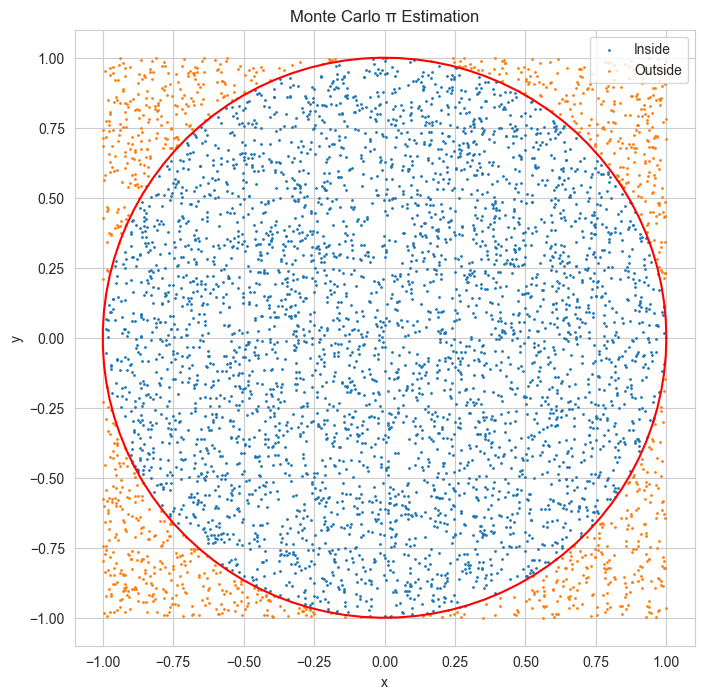

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))

plt.scatter(x[:5000][inside[:5000]], y[:5000][inside[:5000]], s=1, label="Inside")

plt.scatter(x[:5000][~inside[:5000]], y[:5000][~inside[:5000]], s=1, label="Outside")

theta = np.linspace(0, 2*np.pi, 100)
plt.plot(np.cos(theta), np.sin(theta), color='red')

plt.legend()
plt.title("Monte Carlo π Estimation")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [4]:
running_pi = []
counts = []

inside_count = 0

for i in range(1, N+1):
    if inside[i-1]:
        inside_count += 1

    if i % 100 == 0:
        pi_est = 4 * inside_count / i
        running_pi.append(pi_est)
        counts.append(i)

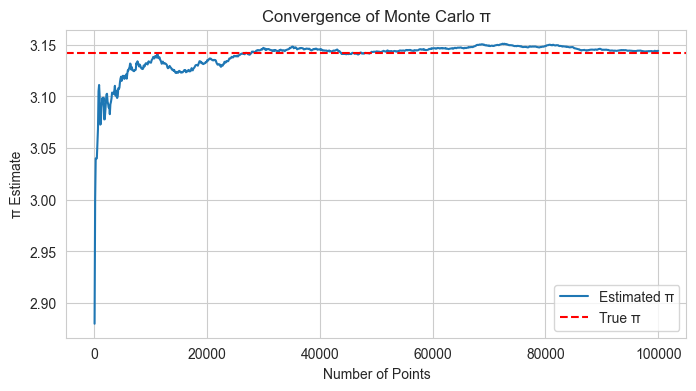

In [5]:
plt.figure(figsize=(8,4))

plt.plot(counts, running_pi, label="Estimated π")
plt.axhline(y=np.pi, linestyle='--', label="True π", color='red')

plt.xlabel("Number of Points")
plt.ylabel("π Estimate")
plt.title("Convergence of Monte Carlo π")
plt.legend()
plt.show()

In [6]:
abs(pi_estimate - np.pi) <= 0.01

np.True_

### Guiding answer
Although the estimate may reach the ±0.01 range at small sample sizes due to randomness, it only becomes consistently stable around 50,000–70,000 samples, where it remains close to the true value of π.

### Task 2: Coin Flips and Empirical Probability

Simulate a series of fair coin flips and observe how the empirical probability of heads converges to 0.5.

1. Simulate **10,000** fair coin flips (use `np.random.choice([0, 1])` or `np.random.binomial(1, 0.5, size=10000)`).
2. Compute the running proportion of heads after each flip (cumulative sum divided by cumulative count).
3. Plot the running proportion with a horizontal line at 0.5. Use a log-scaled x-axis so you can see early fluctuations and later stabilization clearly.
4. Repeat the experiment **5 times** (5 independent series of 10,000 flips) and overlay all 5 convergence paths on the same plot with different colors.

**Guiding question:** How many flips does it typically take for the running proportion to stay within ±0.01 of 0.5?

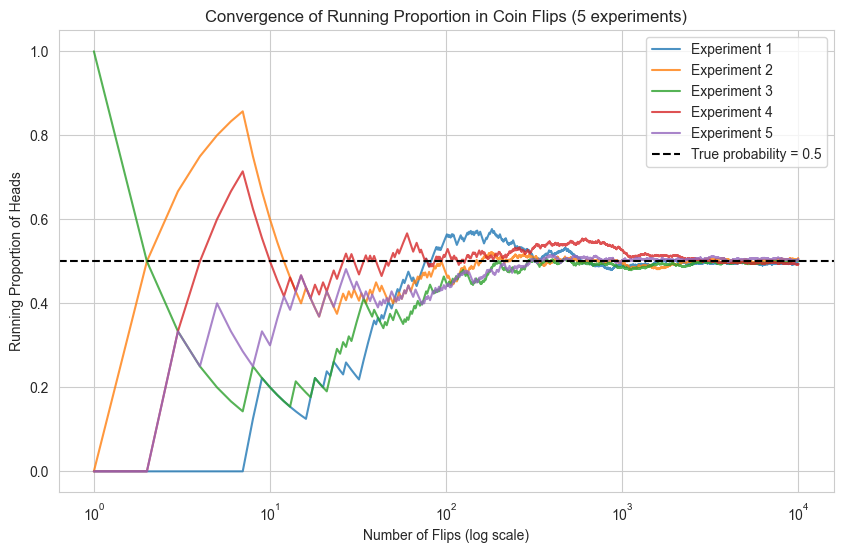

In [7]:
import numpy as np
import matplotlib.pyplot as plt

N = 10000     
experiments = 5 

plt.figure(figsize=(10,6))


for exp in range(experiments):
    flips = np.random.binomial(1, 0.5, size=N)
    
    cumulative_heads = np.cumsum(flips)         
    counts = np.arange(1, N+1)         
    running_proportion = cumulative_heads / counts
    
    plt.plot(counts, running_proportion, label=f'Experiment {exp+1}', alpha=0.8)

plt.axhline(0.5, color='black', linestyle='--', label='True probability = 0.5')

plt.xscale('log')

plt.xlabel('Number of Flips (log scale)')
plt.ylabel('Running Proportion of Heads')
plt.title('Convergence of Running Proportion in Coin Flips (5 experiments)')
plt.legend()
plt.show()

### Guiding answer
Although the proportion may temporarily enter the ±0.01 range earlier due to randomness, true stability is observed only after about 6,000 flips.

### Task 3: Simulating Binomial Experiments

A factory produces widgets with a 3% defect rate. A quality inspector samples 50 widgets per batch.

1. Simulate **10,000 batches** of 50 widgets each, where each widget has a 3% chance of being defective.
2. For each batch, record the number of defective widgets found.
3. Plot a histogram of the defect counts across all 10,000 batches. Overlay the theoretical Binomial(n=50, p=0.03) PMF as points connected by a line.
4. From your simulation, estimate:
   - P(0 defects in a batch)
   - P(3 or more defects in a batch)
   - The expected number of defects per batch
5. Compare each simulation estimate to the theoretical binomial value (use `scipy.stats.binom` or manual calculation).

**Guiding question:** How close are your empirical estimates to the theoretical values? Would 1,000 batches have been enough, or do you need 10,000?

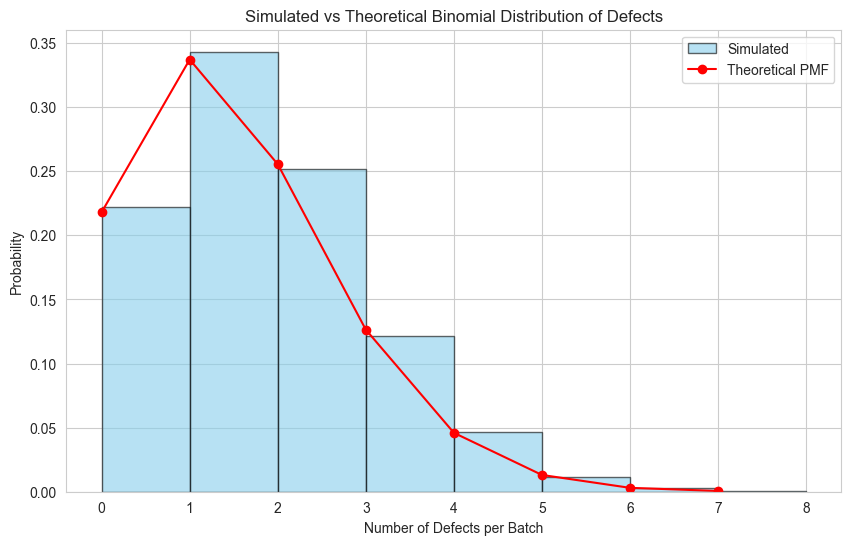

Empirical P(0 defects) = 0.2224
Empirical P(3+ defects) = 0.1828
Empirical Expected defects per batch = 1.48
Theoretical P(0 defects) = 0.2181
Theoretical P(3+ defects) = 0.1892
Theoretical Expected defects per batch = 1.50


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom

n_widgets = 50
p_defect = 0.03
n_batches = 10000

np.random.seed(42)
defects = np.random.binomial(n=n_widgets, p=p_defect, size=n_batches)

plt.figure(figsize=(10,6))
counts, bins, _ = plt.hist(defects, bins=range(0, max(defects)+2), density=True, alpha=0.6, color='skyblue', edgecolor='black', label='Simulated')

k_values = np.arange(0, max(defects)+1)
pmf_values = binom.pmf(k_values, n=n_widgets, p=p_defect)
plt.plot(k_values, pmf_values, 'o-', color='red', label='Theoretical PMF')

plt.xlabel('Number of Defects per Batch')
plt.ylabel('Probability')
plt.title('Simulated vs Theoretical Binomial Distribution of Defects')
plt.legend()
plt.show()

p0_empirical = np.mean(defects == 0)
p3plus_empirical = np.mean(defects >= 3)
expected_defects_empirical = np.mean(defects)

print(f"Empirical P(0 defects) = {p0_empirical:.4f}")
print(f"Empirical P(3+ defects) = {p3plus_empirical:.4f}")
print(f"Empirical Expected defects per batch = {expected_defects_empirical:.2f}")

p0_theoretical = binom.pmf(0, n_widgets, p_defect)
p3plus_theoretical = 1 - binom.cdf(2, n_widgets, p_defect)
expected_defects_theoretical = n_widgets * p_defect

print(f"Theoretical P(0 defects) = {p0_theoretical:.4f}")
print(f"Theoretical P(3+ defects) = {p3plus_theoretical:.4f}")
print(f"Theoretical Expected defects per batch = {expected_defects_theoretical:.2f}")